# Elevator Vibration — Comprehensive Analysis / 电梯振动综合分析

**Serial**: S0783L01A | **Sensor**: Door-mounted (single side) / 门装传感器（单边）  
**Dates**: 2026-04-29 & 2026-03-30 | **Trips**: 1, 10, 100, 101, 102  
**Axes**: X=door open dir / 门开关方向, Y=lateral / 侧向, Z=vertical / 垂直  
**Modules**: preprocessing | time_domain | frequency | ride_quality | state_detection | diagnostics | visualization

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(0, "../src")
from elevator_vibration import preprocessing as pp
from elevator_vibration import time_domain as td
from elevator_vibration import frequency as freq
from elevator_vibration import ride_quality as rq
from elevator_vibration import state_detection as sd
from elevator_vibration import diagnostics as diag

plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (14, 6)})
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
np.set_printoptions(precision=3, suppress=True)

In [2]:
def load_jsonl(path):
    recs = [json.loads(l) for l in open(path) if l.strip()]
    n = len(recs)
    ax = np.array([r['ax'] for r in recs])
    ay = np.array([r['ay'] for r in recs])
    az = np.array([r['az'] for r in recs])
    t = np.arange(n) / 100.0
    return ax, ay, az, t

DATA = Path("../data/samples")
april_files = sorted(DATA.glob('S0783L01A_2026-04-29_trip*.jsonl'))
march_files = sorted(DATA.glob('march30/*.jsonl'))

all_trips = {}
for label, files in [("April 29", april_files), ("March 30", march_files)]:
    for fpath in files:
        ax, ay, az, t = load_jsonl(fpath)
        all_trips[fpath.stem] = {'ax': ax, 'ay': ay, 'az': az, 't': t, 'date': label}

print(f"Loaded {len(all_trips)} trips")
for k, v in sorted(all_trips.items()):
    print(f"  {v['date']}: {k} | {len(v['ax'])} samples, {v['t'][-1]:.1f}s")

Loaded 10 trips
  March 30: 2026-03-30T05:30:36:598915-2026-03-30T05:31:13:634498-f1-t10 | 4405 samples, 44.0s
  March 30: 2026-03-30T07:36:31:367591-2026-03-30T07:37:08:741615-f1-t10 | 4444 samples, 44.4s
  March 30: 2026-03-30T17:22:38:079049-2026-03-30T17:22:53:783937-f10-t12 | 2274 samples, 22.7s
  March 30: 2026-03-30T17:22:59:207852-2026-03-30T17:23:15:726047-f12-t14 | 2199 samples, 22.0s
  March 30: 2026-03-30T17:23:22:554489-2026-03-30T17:23:35:883600-f14-t13 | 2020 samples, 20.2s
  April 29: S0783L01A_2026-04-29_trip1 | 4453 samples, 44.5s
  April 29: S0783L01A_2026-04-29_trip10 | 4452 samples, 44.5s
  April 29: S0783L01A_2026-04-29_trip100 | 2716 samples, 27.1s
  April 29: S0783L01A_2026-04-29_trip101 | 4413 samples, 44.1s
  April 29: S0783L01A_2026-04-29_trip102 | 4697 samples, 47.0s


## 0. Sensor Context / 传感器安装说明

**Door-mounted, single side / 门装传感器，单侧安装**

| Axis | Direction / 方向 | What it measures / 测量内容 |
|:-----|:-----------------|:---------------------------|
| X | Door open/close / 门开关方向 | Door rattle, door operation / 门板振动、门操作 |
| Y | Lateral along door / 门平面侧向 | Sideway sway / 侧向摆动 |
| Z | Vertical / 垂直 | Ride dynamics, gravity / 运行动态、重力 |

> ⚠️ **All data = door panel vibration, NOT car body / 所有数据反映门板振动，不是轿厢本体**

## 1. Preprocessing & Batch State Detection / 预处理与批量状态检测

In [3]:
# Run full pipeline on all trips
state_results = {}
qc_results = []

for name, trip in sorted(all_trips.items()):
    ax, ay, az, t = trip['ax'], trip['ay'], trip['az'], trip['t']
    dt = np.median(np.diff(t))
    
    az_dyn, gravity = pp.separate_gravity(az)
    noise = pp.estimate_noise_floor(ax, ay, az)
    door_mask = pp.door_operation_mask(ax)
    
    st = sd.analyze_trip_states(ax, ay, az, t, dt)
    state_results[name] = st
    
    qc_results.append({
        'name': name, 'date': trip['date'], 'dur': t[-1],
        'gravity': gravity, 'n': len(ax),
        'noise_x_mg': noise['ax_noise_rms']*1000,
        'noise_y_mg': noise['ay_noise_rms']*1000,
        'noise_z_mg': noise['az_noise_rms']*1000,
        'door_pct': door_mask.mean()*100,
        'az_dyn': az_dyn,
    })

print(f"{'Name':<45} {'Date':<10} {'Grav':>6} {'NoiseXY':>14} {'NoiseZ':>8} {'Door%':>7}")
print("-" * 95)
for q in qc_results:
    print(f"{q['name']:<45} {q['date']:<10} {q['gravity']:6.4f} {q['noise_x_mg']:6.2f},{q['noise_y_mg']:6.2f} {q['noise_z_mg']:8.3f} {q['door_pct']:7.2f}")

Name                                          Date         Grav        NoiseXY   NoiseZ   Door%
-----------------------------------------------------------------------------------------------
2026-03-30T05:30:36:598915-2026-03-30T05:31:13:634498-f1-t10 March 30   0.9981   3.22,  3.69    6.888    0.00
2026-03-30T07:36:31:367591-2026-03-30T07:37:08:741615-f1-t10 March 30   0.9981   3.59,  4.20    8.269    0.00
2026-03-30T17:22:38:079049-2026-03-30T17:22:53:783937-f10-t12 March 30   0.9982   4.49,  4.24    2.164    0.00
2026-03-30T17:22:59:207852-2026-03-30T17:23:15:726047-f12-t14 March 30   0.9983   2.36,  2.31    1.399    0.00
2026-03-30T17:23:22:554489-2026-03-30T17:23:35:883600-f14-t13 March 30   0.9982   3.71,  2.58    2.935    0.00
S0783L01A_2026-04-29_trip1                    April 29   0.9983   3.26,  3.07    3.384    0.00
S0783L01A_2026-04-29_trip10                   April 29   0.9983   4.27,  4.46    9.203    0.00
S0783L01A_2026-04-29_trip100                  April 29   0.9982  

## 2. Visualizations / 可视化

### 2.1 Phase Timeline — State Detection / 状态检测相位时间线

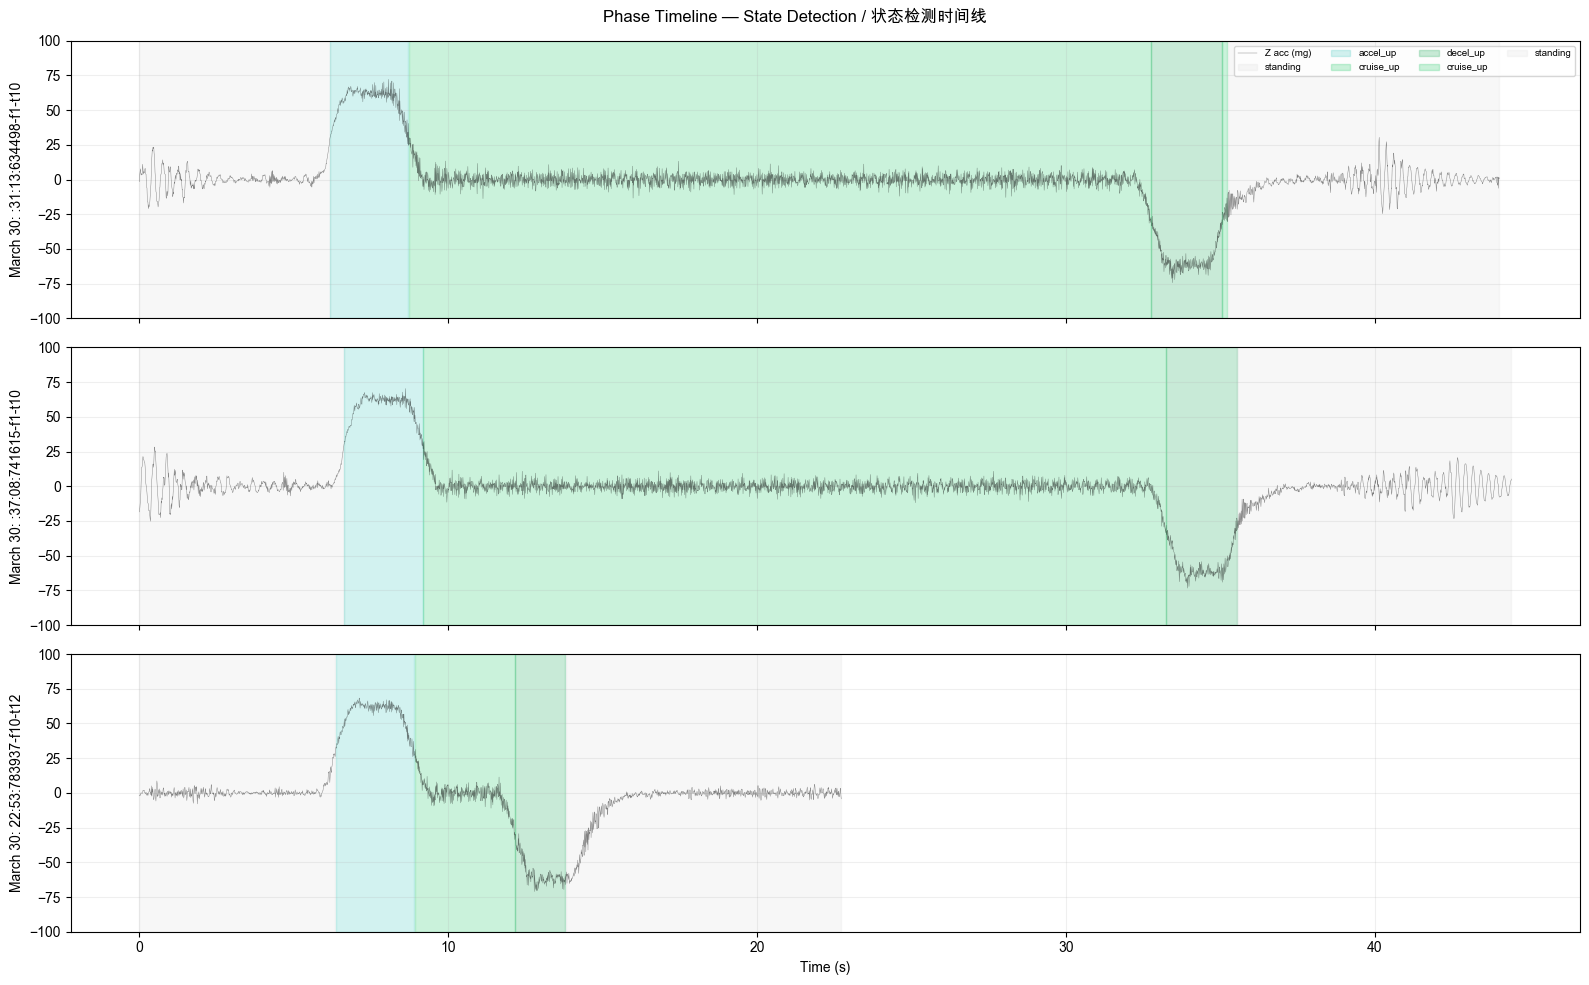

In [4]:
# Plot phase timelines for first 3 trips
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

color_map = {
    'standing': '#e0e0e0', 'accel_up': '#4ecdc4', 'cruise_up': '#2ecc71',
    'decel_up': '#27ae60', 'accel_down': '#e74c3c', 'cruise_down': '#f39c12',
    'decel_down': '#d35400', 'door_operation': '#9b59b6',
}

sample_trips = list(state_results.items())[:3]
for idx, (name, st) in enumerate(sample_trips):
    ax = axes[idx]
    trip = all_trips[name]
    t = trip['t']
    az_dyn = qc_results[[q['name'] for q in qc_results].index(name)]['az_dyn']
    
    # Plot Z acceleration
    ax.plot(t, az_dyn*1000, 'k-', linewidth=0.3, alpha=0.5, label='Z acc (mg)')
    
    # Overlay state bands
    for p in st.phases:
        color = color_map.get(p.state, '#cccccc')
        ax.axvspan(p.t_start, p.t_end, alpha=0.25, color=color, label=p.state if idx == 0 else '')
    
    ax.set_ylabel(f"{trip['date']}: {name[-20:]}")
    ax.set_ylim(-100, 100)
    ax.grid(alpha=0.2)

axes[0].legend(loc='upper right', ncol=4, fontsize=7)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Phase Timeline — State Detection / 状态检测时间线', fontweight='bold')
fig.tight_layout()
plt.show()

### 2.2 Door Rattle Across All Trips / 各 Trip 门松动指数对比

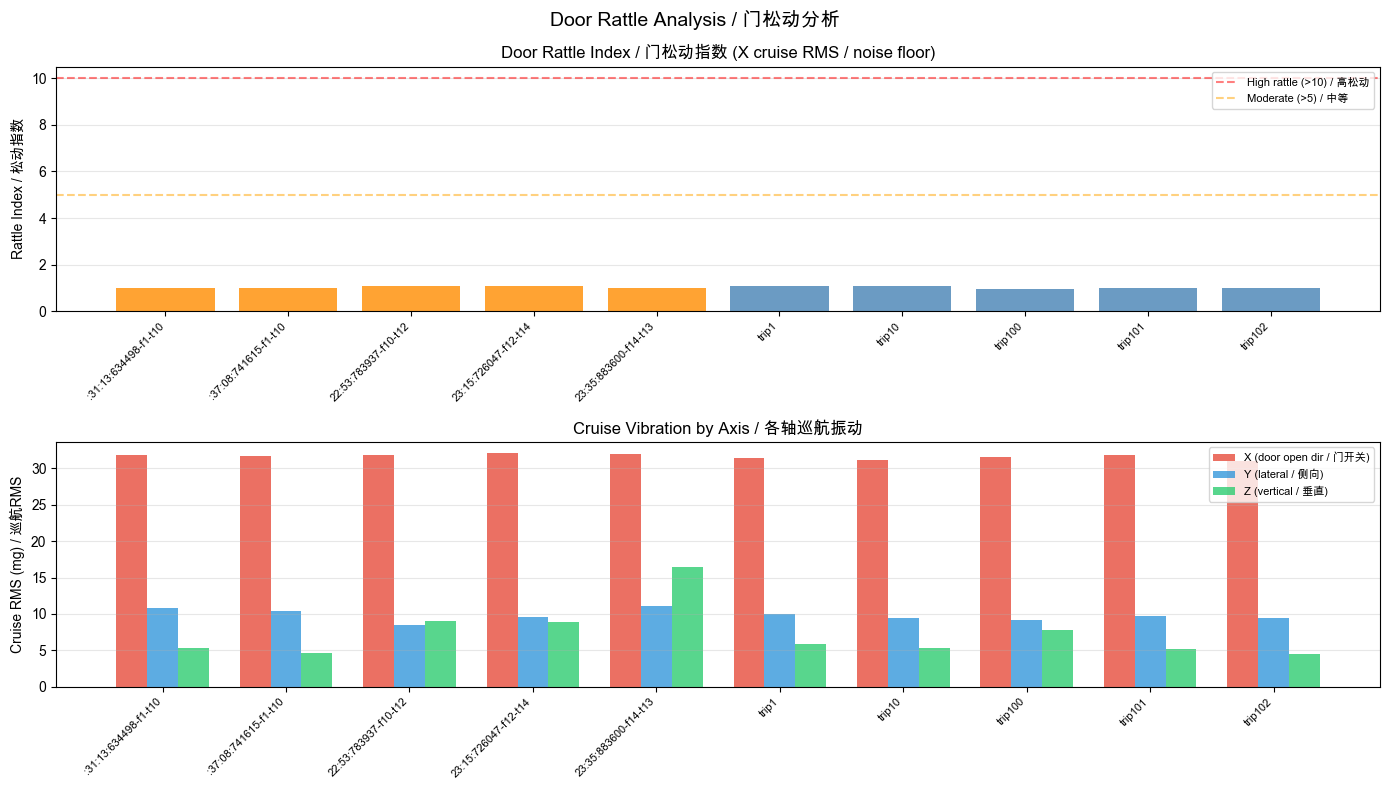

In [5]:
# Door rattle visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

trip_names = []
rattle_vals = []
x_cruise_vals = []
y_cruise_vals = []
z_cruise_vals = []
dates_list = []

for name in sorted(all_trips.keys()):
    trip = all_trips[name]
    st = state_results[name]
    ax_d, ay_d, az_d, t_d = trip['ax'], trip['ay'], trip['az'], trip['t']
    _, az_dyn = pp.separate_gravity(az_d)[:2] if False else (None, None)
    az_dyn, _ = pp.separate_gravity(az_d)
    
    cruise_mask = np.isin(st.state_codes, [sd.STATE_CRUISE_UP, sd.STATE_CRUISE_DOWN])
    xc = td.compute_rms(ax_d[cruise_mask])*1000 if np.any(cruise_mask) else 0
    yc = td.compute_rms(ay_d[cruise_mask])*1000 if np.any(cruise_mask) else 0
    zc = td.compute_rms(az_dyn[cruise_mask])*1000 if np.any(cruise_mask) else 0
    
    short_name = name.replace('S0783L01A_2026-04-29_', '').replace('.jsonl', '')
    if 'march30' in str(DATA):
        short_name = name.split('/')[-1][:25] if '/' in name else name[:25]
    
    trip_names.append(short_name[-20:])
    rattle_vals.append(st.door_rattle_index)
    x_cruise_vals.append(xc)
    y_cruise_vals.append(yc)
    z_cruise_vals.append(zc)
    dates_list.append(trip['date'])

colors = ['steelblue' if d == 'April 29' else 'darkorange' for d in dates_list]

# Bar: door rattle index
ax = axes[0]
bars = ax.bar(range(len(trip_names)), rattle_vals, color=colors, alpha=0.8)
ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='High rattle (>10) / 高松动')
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='Moderate (>5) / 中等')
ax.set_xticks(range(len(trip_names)))
ax.set_xticklabels(trip_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rattle Index / 松动指数')
ax.legend(fontsize=8)
ax.set_title('Door Rattle Index / 门松动指数 (X cruise RMS / noise floor)')
ax.grid(axis='y', alpha=0.3)

# Bar: X vs Y vs Z cruise RMS
ax = axes[1]
x_pos = np.arange(len(trip_names))
w = 0.25
ax.bar(x_pos - w, x_cruise_vals, w, label='X (door open dir / 门开关)', color='#e74c3c', alpha=0.8)
ax.bar(x_pos, y_cruise_vals, w, label='Y (lateral / 侧向)', color='#3498db', alpha=0.8)
ax.bar(x_pos + w, z_cruise_vals, w, label='Z (vertical / 垂直)', color='#2ecc71', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(trip_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cruise RMS (mg) / 巡航RMS')
ax.legend(fontsize=8)
ax.set_title('Cruise Vibration by Axis / 各轴巡航振动')
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Door Rattle Analysis / 门松动分析', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.show()

### 2.3 Frequency Spectrum Comparison / 频谱对比

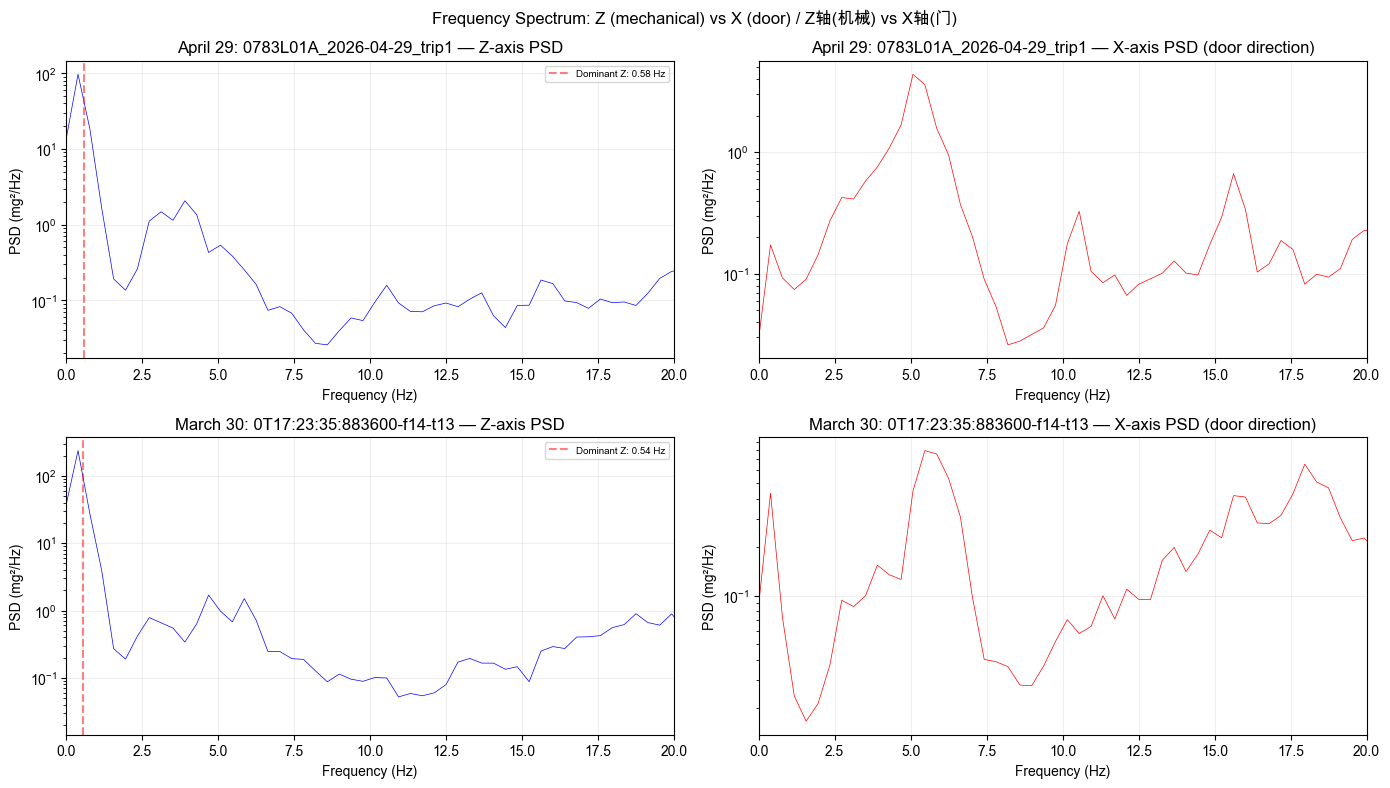

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Pick two representative trips
trip_keys = list(all_trips.keys())
for plot_idx, key in enumerate([trip_keys[0], trip_keys[-1]]):
    trip = all_trips[key]
    ax_d, ay_d, az_d, t_d = trip['ax'], trip['ay'], trip['az'], trip['t']
    dt = np.median(np.diff(t_d))
    fs = 1.0/dt
    az_dyn, _ = pp.separate_gravity(az_d)
    
    # Z-axis PSD
    f_psd, psd_z = freq.compute_psd(az_dyn, fs=fs)
    ax = axes[plot_idx, 0]
    ax.semilogy(f_psd, psd_z * 1e6, 'b-', linewidth=0.5)
    ax.set_xlim(0, 20)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (mg²/Hz)')
    dom_z = freq.dominant_frequency(*freq.compute_fft(az_dyn, fs=fs), 0.5, 50)
    ax.axvline(x=dom_z, color='red', linestyle='--', alpha=0.5, label=f'Dominant Z: {dom_z:.2f} Hz')
    ax.set_title(f"{trip['date']}: {key[-25:]} — Z-axis PSD")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
    
    # X-axis PSD
    f_psd_x, psd_x = freq.compute_psd(ax_d, fs=fs)
    ax = axes[plot_idx, 1]
    ax.semilogy(f_psd_x, psd_x * 1e6, 'r-', linewidth=0.5)
    ax.set_xlim(0, 20)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (mg²/Hz)')
    ax.set_title(f"{trip['date']}: {key[-25:]} — X-axis PSD (door direction)")
    ax.grid(alpha=0.2)

fig.suptitle('Frequency Spectrum: Z (mechanical) vs X (door) / Z轴(机械) vs X轴(门)', fontweight='bold')
fig.tight_layout()
plt.show()

### 2.4 Ride Quality — Z-Only vs Full Contamination / 乘坐质量：Z轴 vs 全轴污染对比

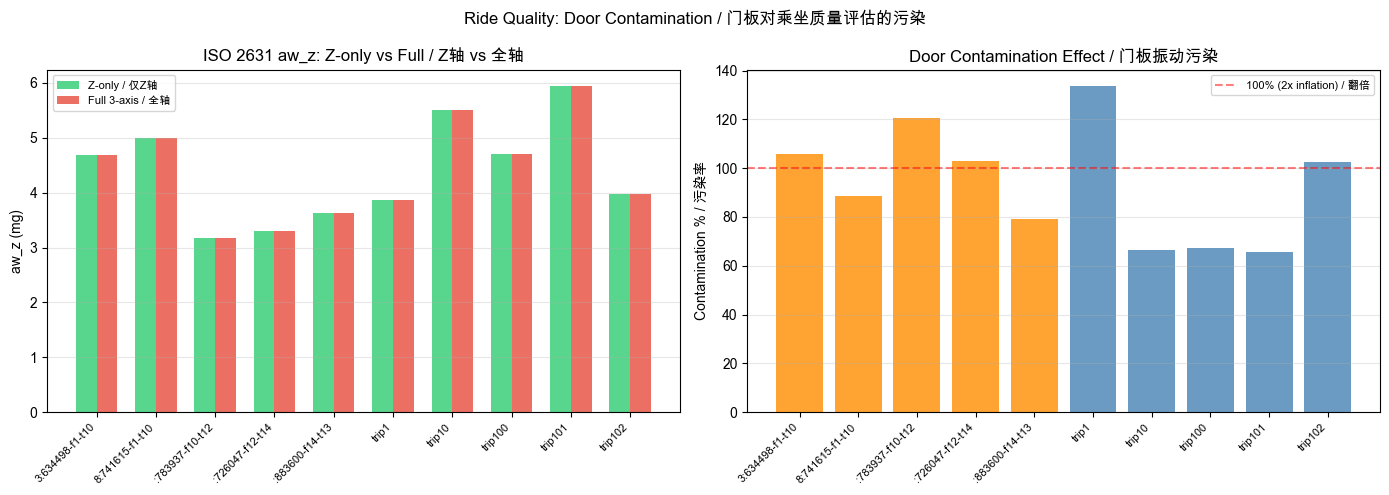

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aw_z_vals, aw_full_vals, contam_vals, labels = [], [], [], []

for name in sorted(all_trips.keys()):
    trip = all_trips[name]
    ax_d, ay_d, az_d, t_d = trip['ax'], trip['ay'], trip['az'], trip['t']
    dt = np.median(np.diff(t_d))
    fs = 1.0/dt
    
    iso_full = rq.iso2631_assessment(ax_d, ay_d, az_d, fs=fs)
    iso_z = rq.iso2631_z_only(az_d, fs=fs)
    
    aw_z_vals.append(iso_z['aw_z']*1000)
    aw_full_vals.append(iso_full['aw_z']*1000)
    contam = (iso_full['av_total'] - iso_z['av_total']) / max(iso_z['av_total'], 1e-12) * 100
    contam_vals.append(contam)
    labels.append(name.replace('S0783L01A_2026-04-29_', '')[-15:])

# Left: Z-only vs Full comparison
ax = axes[0]
x = range(len(labels))
w = 0.35
ax.bar([i-w/2 for i in x], aw_z_vals, w, label='Z-only / 仅Z轴', color='#2ecc71', alpha=0.8)
ax.bar([i+w/2 for i in x], aw_full_vals, w, label='Full 3-axis / 全轴', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('aw_z (mg)')
ax.set_title('ISO 2631 aw_z: Z-only vs Full / Z轴 vs 全轴')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Right: Contamination %
ax = axes[1]
colors = ['steelblue' if all_trips[n]['date'] == 'April 29' else 'darkorange' for n in sorted(all_trips.keys())]
ax.bar(x, contam_vals, color=colors, alpha=0.8)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% (2x inflation) / 翻倍')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Contamination % / 污染率')
ax.set_title('Door Contamination Effect / 门板振动污染')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Ride Quality: Door Contamination / 门板对乘坐质量评估的污染', fontweight='bold')
fig.tight_layout()
plt.show()

## 3. Per-Date Merged Diagnostics / 按日期合并诊断

Some diagnostics need multiple trips (bearing trend, guide wear). Merge all trips from the same date.

In [8]:
# Per-date aggregate diagnostics
for date_label in ["April 29", "March 30"]:
    date_trips = [(name, trip) for name, trip in all_trips.items() if trip['date'] == date_label]
    print(f"\n{'='*60}")
    print(f"  {date_label} — Merged Diagnostics / 合并诊断 ({len(date_trips)} trips)")
    print(f"{'='*60}")
    
    kurtosis_trend = []
    health_scores = []
    rattle_indices = []
    
    for name, trip in date_trips:
        ax_d, ay_d, az_d, t_d = trip['ax'], trip['ay'], trip['az'], trip['t']
        dt = np.median(np.diff(t_d))
        az_dyn, _ = pp.separate_gravity(az_d)
        st = state_results[name]
        
        report = diag.full_diagnostic_report(ax_d, ay_d, az_d, t_d, dt, st)
        health_scores.append(report['health_score'])
        rattle_indices.append(st.door_rattle_index)
        kurtosis_trend.append(td.compute_kurtosis(az_dyn))
        
        print(f"  Trip {name[-15:]:<20} Health={report['health_score']}/100  Rattle={st.door_rattle_index:.1f}  KurtosisZ={td.compute_kurtosis(az_dyn):.2f}")
    
    # Bearing trend (needs multi-trip)
    bearing = diag.diagnose_bearing_degradation(kurtosis_trend, [])
    print(f"\n  Avg Health / 平均健康: {np.mean(health_scores):.0f}/100")
    print(f"  Avg Rattle / 平均松动: {np.mean(rattle_indices):.1f}")
    print(f"  Bearing Trend / 轴承趋势: severity={bearing['severity']}, n_inc={bearing['n_increasing']}")
    print(f"  {bearing['recommendation']}")


  April 29 — Merged Diagnostics / 合并诊断 (5 trips)
  Trip 026-04-29_trip1      Health=95/100  Rattle=1.1  KurtosisZ=5.82
  Trip 26-04-29_trip10      Health=95/100  Rattle=1.1  KurtosisZ=5.20
  Trip 6-04-29_trip100      Health=100/100  Rattle=0.9  KurtosisZ=2.45
  Trip 6-04-29_trip101      Health=95/100  Rattle=1.0  KurtosisZ=4.96
  Trip 6-04-29_trip102      Health=95/100  Rattle=1.0  KurtosisZ=6.19

  Avg Health / 平均健康: 96/100
  Avg Rattle / 平均松动: 1.0
  Bearing Trend / 轴承趋势: severity=elevated, n_inc=3
  Emerging bearing degradation trend (3 trips). Increase monitoring frequency and inspect at next maintenance.

  March 30 — Merged Diagnostics / 合并诊断 (5 trips)
  Trip 3:634498-f1-t10      Health=95/100  Rattle=1.0  KurtosisZ=5.48
  Trip 8:741615-f1-t10      Health=95/100  Rattle=1.0  KurtosisZ=5.43
  Trip :783937-f10-t12      Health=100/100  Rattle=1.1  KurtosisZ=1.70
  Trip :726047-f12-t14      Health=90/100  Rattle=1.1  KurtosisZ=1.56
  Trip :883600-f14-t13      Health=100/100  Rattle=1

## 4. Door Operation Detection / 门操作检测

Can we detect door open/close from X-axis data? / 能否从X轴数据检测开关门？

**原理**: Door opening/closing moves the door panel in X direction, producing characteristic X-axis acceleration.
门开关时门板在X方向移动，产生特征的X轴加速度。

In [9]:
def detect_door_events_detailed(ax, t, dt, st):
    """Detailed door event detection: find X-axis activity during standing phases."""
    events = []
    # Look at standing phases between runs
    standing_phases = [p for p in st.phases if p.state == 'standing' and p.duration > 2.0]
    
    for sp in standing_phases:
        idx_s = sp.idx_start
        idx_e = sp.idx_end
        ax_seg = ax[idx_s:idx_e]
        t_seg = t[idx_s:idx_e]
        
        # Door event: X-axis RMS spikes during otherwise quiet standing
        rms_x = td.compute_rms(ax_seg)
        peak_x = td.compute_peak(ax_seg)
        
        # Door operation typically 50-200 mg in X
        if rms_x > 0.015:  # 15 mg threshold for door movement
            events.append({
                't_start': sp.t_start, 't_end': sp.t_end,
                'duration': sp.duration,
                'rms_x_mg': rms_x * 1000,
                'peak_x_mg': peak_x * 1000,
                'likely_door': rms_x > 0.020,  # Strong indicator
            })
    return events

print("Door Event Detection / 门事件检测:")
print("-" * 70)
for name in sorted(all_trips.keys())[:3]:
    trip = all_trips[name]
    st = state_results[name]
    events = detect_door_events_detailed(trip['ax'], trip['t'], 0.01, st)
    
    print(f"\n{trip['date']}: {name[-25:]}")
    if events:
        for ev in events:
            door_str = 'DOOR!' if ev['likely_door'] else 'movement?'
            print(f"  Standing {ev['t_start']:.1f}-{ev['t_end']:.1f}s: "
                  f"RMSx={ev['rms_x_mg']:.1f}mg Peakx={ev['peak_x_mg']:.1f}mg → {door_str}")
    else:
        print(f"  No door events detected / 未检测到门事件")

Door Event Detection / 门事件检测:
----------------------------------------------------------------------

March 30: 30T05:31:13:634498-f1-t10
  Standing 0.0-6.2s: RMSx=31.4mg Peakx=46.5mg → DOOR!
  Standing 35.2-44.0s: RMSx=31.7mg Peakx=47.5mg → DOOR!

March 30: 30T07:37:08:741615-f1-t10
  Standing 0.0-6.6s: RMSx=31.6mg Peakx=51.9mg → DOOR!
  Standing 35.6-44.4s: RMSx=31.7mg Peakx=44.1mg → DOOR!

March 30: 0T17:22:53:783937-f10-t12
  Standing 0.0-6.3s: RMSx=31.8mg Peakx=48.6mg → DOOR!
  Standing 13.8-22.7s: RMSx=31.2mg Peakx=43.9mg → DOOR!


## 5. Occupancy Estimation / 载人估计

Can we tell if the elevator is empty or loaded? / 能否判断空载还是有人？

**Indicators / 指标**:
- People entering/exiting → X-axis & Z-axis activity during standing after arrival
- 人员进出 → 到达后静止段的X轴和Z轴活动
- Load affects acceleration phase (heavier → different motor response)
- 载重影响加速段特征

In [10]:
def estimate_occupancy(ax, ay, az, t, st):
    """Estimate if elevator had passengers based on vibration patterns."""
    indicators = {}
    az_dyn, _ = pp.separate_gravity(az)
    
    # 1. Standing segment activity (people moving = X+Z spikes)
    standing_phases = [p for p in st.phases if p.state == 'standing' and p.duration > 2.0]
    standing_x_rms = []
    standing_z_rms = []
    for sp in standing_phases:
        standing_x_rms.append(td.compute_rms(ax[sp.idx_start:sp.idx_end]) * 1000)
        standing_z_rms.append(td.compute_rms(az_dyn[sp.idx_start:sp.idx_end]) * 1000)
    
    indicators['standing_x_rms_avg_mg'] = np.mean(standing_x_rms) if standing_x_rms else 0
    indicators['standing_z_rms_avg_mg'] = np.mean(standing_z_rms) if standing_z_rms else 0
    
    # 2. Accel phase jerk (higher with load due to motor response)
    accel_phases = [p for p in st.phases if 'accel' in p.state]
    if accel_phases:
        jerk_vals = []
        for ap in accel_phases:
            j = td.compute_jerk_rms(az_dyn[ap.idx_start:ap.idx_end])
            jerk_vals.append(j)
        indicators['accel_jerk_rms'] = np.mean(jerk_vals)
    else:
        indicators['accel_jerk_rms'] = 0
    
    # 3. Z-axis peak during accel (higher load → potentially higher peak)
    if accel_phases:
        peak_vals = [td.compute_peak(az_dyn[ap.idx_start:ap.idx_end]) * 1000 for ap in accel_phases]
        indicators['accel_peak_z_mg'] = np.mean(peak_vals)
    
    # Heuristic: if standing X RMS > 10 mg, likely people moving
    people_activity = indicators['standing_x_rms_avg_mg'] > 10.0
    indicators['likely_occupied'] = people_activity
    indicators['confidence'] = 'medium' if people_activity else 'low'
    
    return indicators

print("Occupancy Estimation / 载人估计:")
print("-" * 70)
for name in sorted(all_trips.keys())[:5]:
    trip = all_trips[name]
    occ = estimate_occupancy(trip['ax'], trip['ay'], trip['az'], trip['t'], state_results[name])
    status = 'Occupied / 有人' if occ['likely_occupied'] else 'Empty? / 空载?'
    print(f"{trip['date']} {name[-20:]:<20} StandingX={occ['standing_x_rms_avg_mg']:5.1f}mg "
          f"AccelJerk={occ['accel_jerk_rms']:.3f} AccelPkZ={occ.get('accel_peak_z_mg',0):5.0f}mg → {status}")

Occupancy Estimation / 载人估计:
----------------------------------------------------------------------
March 30 :31:13:634498-f1-t10 StandingX= 31.6mg AccelJerk=0.238 AccelPkZ=   72mg → Occupied / 有人
March 30 :37:08:741615-f1-t10 StandingX= 31.7mg AccelJerk=0.161 AccelPkZ=   70mg → Occupied / 有人
March 30 22:53:783937-f10-t12 StandingX= 31.5mg AccelJerk=0.175 AccelPkZ=   68mg → Occupied / 有人
March 30 23:15:726047-f12-t14 StandingX= 31.3mg AccelJerk=0.192 AccelPkZ=   69mg → Occupied / 有人
March 30 23:35:883600-f14-t13 StandingX= 31.8mg AccelJerk=0.295 AccelPkZ=   58mg → Occupied / 有人


## 6. Entrapment Risk Assessment / 困人风险评估

Entrapment indicators / 困人指标:
- Multiple door open/close cycles at same floor without movement
- 同一楼层多次开关门但无运行
- Extended standing with elevated X-axis activity (door struggling)
- 静止段延长且X轴活动增加（门反复动作）
- Abnormally long standing periods between runs
- 运行间隔异常延长

In [11]:
def assess_entrapment_risk(st, ax, t):
    """Assess entrapment risk from state detection and X-axis data."""
    risk = {'risk_level': 'low', 'indicators': []}
    
    # 1. Check for repeated door cycles at same floor
    door_ops = st.door_events_detected
    if door_ops >= 3:
        risk['indicators'].append(f'Multiple door cycles ({door_ops})')
        risk['risk_level'] = 'elevated'
    
    # 2. Check for abnormally long standing periods (>15s between runs)
    standing_phases = [p for p in st.phases if p.state == 'standing']
    long_stands = [p for p in standing_phases if p.duration > 15.0]
    if long_stands:
        risk['indicators'].append(f"Long standing: {long_stands[0].duration:.0f}s")
        if long_stands[0].duration > 30:
            risk['risk_level'] = 'high'
    
    # 3. Check X-axis activity during standing (door struggling)
    for sp in standing_phases:
        if sp.duration > 5:
            x_rms = td.compute_rms(ax[sp.idx_start:sp.idx_end]) * 1000
            if x_rms > 25:  # High X during standing = door activity
                risk['indicators'].append(f"Door struggle: Xrms={x_rms:.0f}mg at {sp.t_start:.0f}s")
                risk['risk_level'] = max(risk['risk_level'], 'elevated')
    
    risk['summary'] = {
        'low': 'Normal / 正常',
        'elevated': 'Check recommended / 建议检查',
        'high': 'URGENT: possible entrapment / 紧急：可能困人'
    }.get(risk['risk_level'], 'Unknown')
    
    return risk

print("Entrapment Risk Assessment / 困人风险评估:")
print("-" * 70)
for name in sorted(all_trips.keys()):
    trip = all_trips[name]
    risk = assess_entrapment_risk(state_results[name], trip['ax'], trip['t'])
    icon = {'low': '✅', 'elevated': '⚠️', 'high': '🚨'}.get(risk['risk_level'], '?')
    print(f"{icon} {trip['date']} {name[-20:]:<20} Risk={risk['risk_level']:<10} {risk['summary']}")
    if risk['indicators']:
        for ind in risk['indicators']:
            print(f"     → {ind}")

Entrapment Risk Assessment / 困人风险评估:
----------------------------------------------------------------------
✅ March 30 :31:13:634498-f1-t10 Risk=low        Normal / 正常
     → Door struggle: Xrms=31mg at 0s
     → Door struggle: Xrms=32mg at 35s
✅ March 30 :37:08:741615-f1-t10 Risk=low        Normal / 正常
     → Door struggle: Xrms=32mg at 0s
     → Door struggle: Xrms=32mg at 36s
✅ March 30 22:53:783937-f10-t12 Risk=low        Normal / 正常
     → Door struggle: Xrms=32mg at 0s
     → Door struggle: Xrms=31mg at 14s
✅ March 30 23:15:726047-f12-t14 Risk=low        Normal / 正常
     → Door struggle: Xrms=31mg at 13s
✅ March 30 23:35:883600-f14-t13 Risk=low        Normal / 正常
     → Door struggle: Xrms=31mg at 0s
     → Door struggle: Xrms=32mg at 11s
✅ April 29 01A_2026-04-29_trip1 Risk=low        Normal / 正常
     → Door struggle: Xrms=31mg at 0s
     → Door struggle: Xrms=31mg at 36s
✅ April 29 1A_2026-04-29_trip10 Risk=low        Normal / 正常
     → Door struggle: Xrms=31mg at 0s
     → Doo

## 7. Cross-Date Health Dashboard / 跨日期健康面板

/var/folders/dp/f3qctbqn2bz8ggkpqfm_7x100000gn/T/ipykernel_40236/2072233248.py:83: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/var/folders/dp/f3qctbqn2bz8ggkpqfm_7x100000gn/T/ipykernel_40236/2072233248.py:83: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/Users/zhzhxtrrk/Workspace/elevator-vibration-analysis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhzhxtrrk/Workspace/elevator-vibration-analysis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


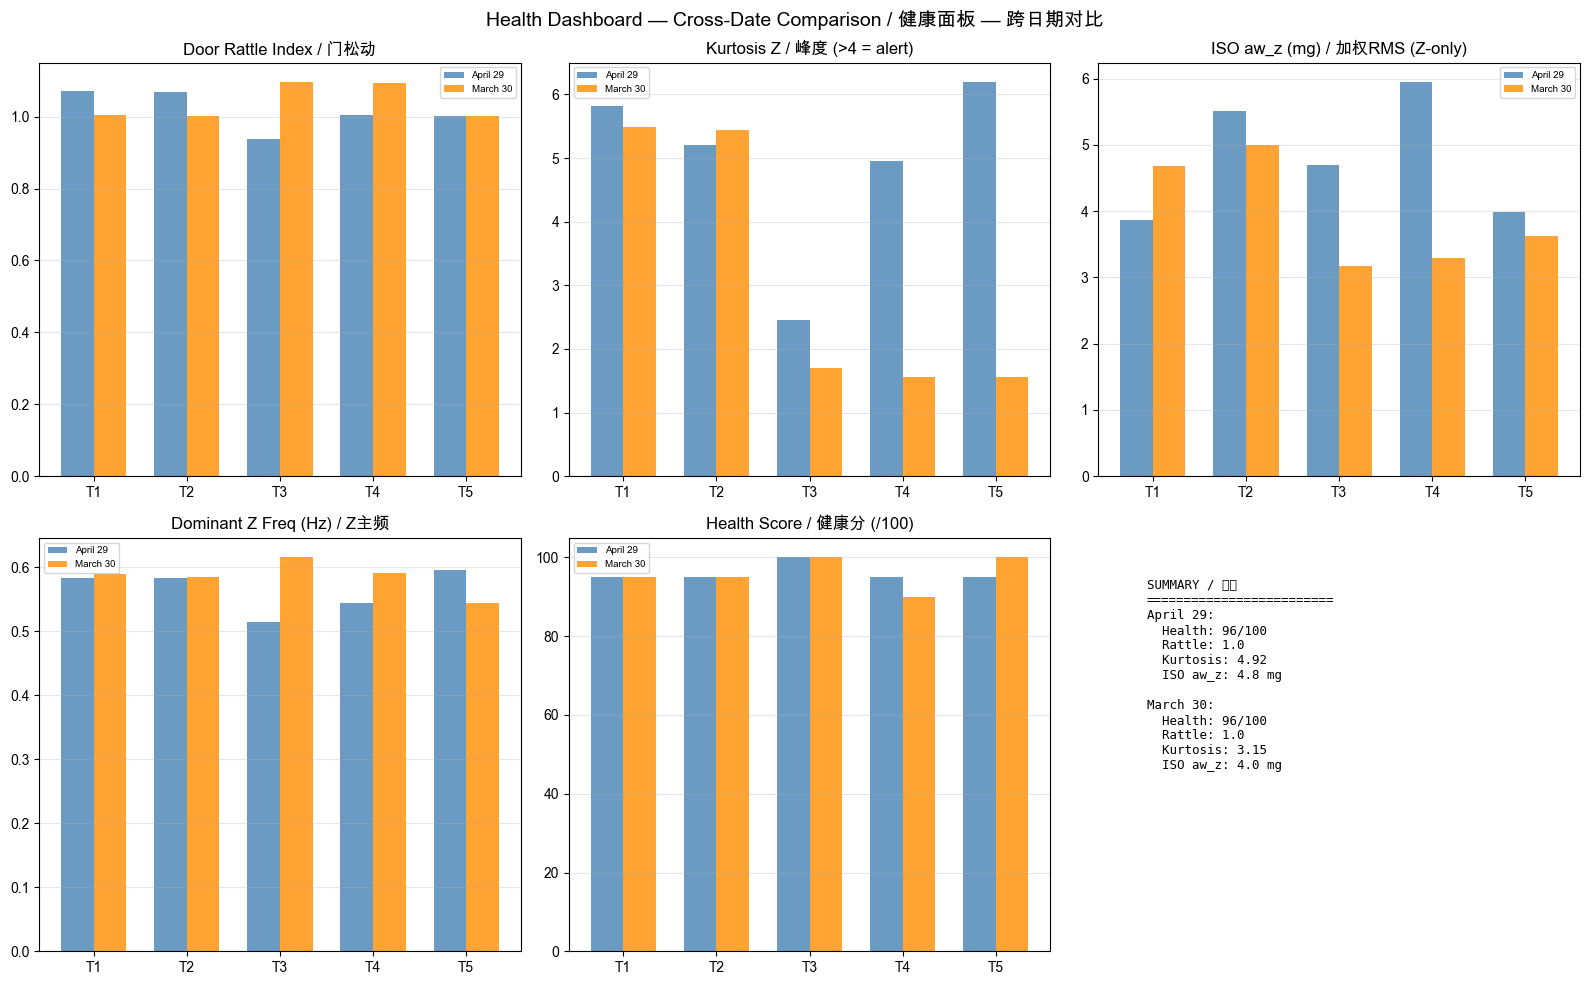

In [12]:
# Aggregate metrics per date
date_metrics = {}
for date_label in ["April 29", "March 30"]:
    trips = [(n, t) for n, t in all_trips.items() if t['date'] == date_label]
    
    kurt_vals = []
    rattle_vals = []
    health_vals = []
    aw_z_vals = []
    dom_z_vals = []
    
    for name, trip in trips:
        st = state_results[name]
        ax_d, ay_d, az_d, t_d = trip['ax'], trip['ay'], trip['az'], trip['t']
        dt = np.median(np.diff(t_d))
        fs = 1.0/dt
        az_dyn, _ = pp.separate_gravity(az_d)
        
        kurt_vals.append(td.compute_kurtosis(az_dyn))
        rattle_vals.append(st.door_rattle_index)
        
        report = diag.full_diagnostic_report(ax_d, ay_d, az_d, t_d, dt, st)
        health_vals.append(report['health_score'])
        
        iso_z = rq.iso2631_z_only(az_d, fs=fs)
        aw_z_vals.append(iso_z['aw_z']*1000)
        
        freqs_z, mag_z = freq.compute_fft(az_dyn, fs=fs)
        dom_z_vals.append(freq.dominant_frequency(freqs_z, mag_z, 0.5, 50))
    
    date_metrics[date_label] = {
        'kurtosis': kurt_vals,
        'rattle': rattle_vals,
        'health': health_vals,
        'aw_z': aw_z_vals,
        'dom_z': dom_z_vals,
    }

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metric_config = [
    ('rattle', 'Door Rattle Index / 门松动', ''),
    ('kurtosis', 'Kurtosis Z / 峰度', '>4 = alert'),
    ('aw_z', 'ISO aw_z (mg) / 加权RMS', 'Z-only'),
    ('dom_z', 'Dominant Z Freq (Hz) / Z主频', ''),
    ('health', 'Health Score / 健康分', '/100'),
]

for i, (key, title, note) in enumerate(metric_config):
    ax = axes[i//3, i%3]
    april_vals = date_metrics['April 29'][key]
    march_vals = date_metrics['March 30'][key]
    
    x = range(len(april_vals))
    w = 0.35
    ax.bar([j-w/2 for j in x], april_vals, w, label='April 29', color='steelblue', alpha=0.8)
    ax.bar([j+w/2 for j in x], march_vals, w, label='March 30', color='darkorange', alpha=0.8)
    ax.set_title(title + (f' ({note})' if note else ''))
    ax.set_xticks(x)
    ax.set_xticklabels([f'T{j+1}' for j in x])
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

# 6th subplot: summary text
ax = axes[1, 2]
ax.axis('off')
summary_lines = [
    "SUMMARY / 总结",
    "=" * 25,
]
for date_label in ["April 29", "March 30"]:
    dm = date_metrics[date_label]
    summary_lines.append(f"{date_label}:")
    summary_lines.append(f"  Health: {np.mean(dm['health']):.0f}/100")
    summary_lines.append(f"  Rattle: {np.mean(dm['rattle']):.1f}")
    summary_lines.append(f"  Kurtosis: {np.mean(dm['kurtosis']):.2f}")
    summary_lines.append(f"  ISO aw_z: {np.mean(dm['aw_z']):.1f} mg")
    summary_lines.append("")
ax.text(0.1, 0.9, '\n'.join(summary_lines), transform=ax.transAxes,
        fontfamily='monospace', fontsize=9, verticalalignment='top')

fig.suptitle('Health Dashboard — Cross-Date Comparison / 健康面板 — 跨日期对比', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.show()

## 8. Bilingual Dynamic Report / 中英双语动态报告

Generate a comprehensive report with Chinese and English, including all findings.

In [13]:
import pandas as pd
from datetime import datetime

def build_bilingual_report(all_trips, state_results, qc_results, date_metrics):
    L = []
    now = datetime.now().strftime('%Y-%m-%d %H:%M')
    
    L.append("# Elevator Vibration Analysis Report / 电梯振动分析报告")
    L.append(f"**Generated / 生成时间**: {now}")
    L.append(f"**Serial / 序列号**: S0783L01A")
    L.append(f"**Sensor / 传感器**: Door-mounted, single side / 门装传感器（单边）")
    L.append("")
    
    # 1. Sensor Configuration
    L.append("## 1. Sensor Configuration / 传感器配置")
    L.append("")
    L.append("The accelerometer is mounted on the elevator **door panel** (single side).")
    L.append("加速度计安装在电梯**门板**上（单侧）。")
    L.append("")
    L.append("| Axis / 轴 | Direction / 方向 | What It Measures / 测量内容 |")
    L.append("|:---------|:-----------------|:---------------------------|")
    L.append("| X | Door open/close / 门开关方向 | Door rattle & door operation / 门板振动和门操作 |")
    L.append("| Y | Lateral along door / 门平面侧向 | Sideways sway / 侧向摆动 |")
    L.append("| Z | Vertical / 垂直 | Ride dynamics & gravity / 运行动态和重力 |")
    L.append("")
    L.append("> ⚠️ **Important / 重要**: All vibration measurements represent **door panel vibration**, NOT car body vibration.")
    L.append("> 所有振动测量反映的是**门板振动**，不是轿厢本体振动。")
    L.append("> For ride quality assessment, **Z-only ISO 2631 mode is recommended** (X/Y contaminated by door).")
    L.append("> 乘坐质量评估建议使用**仅Z轴ISO 2631模式**（X/Y受门板污染）。")
    L.append("")
    
    # 2. Data Overview
    L.append("## 2. Data Overview / 数据概览")
    L.append("")
    total_trips = len(all_trips)
    april_count = sum(1 for t in all_trips.values() if t['date'] == 'April 29')
    march_count = sum(1 for t in all_trips.values() if t['date'] == 'March 30')
    L.append(f"- {total_trips} trips analyzed / 个行程已分析")
    L.append(f"- April 29: {april_count} trips | March 30: {march_count} trips")
    L.append(f"- 1-month interval / 一个月间隔")
    L.append("")
    
    # 3. Key Findings Per Trip
    L.append("## 3. Per-Trip Analysis / 各行程分析")
    L.append("")
    
    for name in sorted(all_trips.keys()):
        trip = all_trips[name]
        st = state_results[name]
        qc = [q for q in qc_results if q['name'] == name][0]
        
        L.append(f"### {trip['date']} — {name[-25:]}")
        L.append("")
        L.append(f"| Metric / 指标 | Value / 值 | Note / 说明 |")
        L.append(f"|:--------------|:----------|:------------|")
        L.append(f"| Direction / 方向 | {st.direction} | |")
        L.append(f"| Duration / 时长 | {trip['t'][-1]:.1f}s | |")
        L.append(f"| Samples / 采样 | {len(trip['ax'])} | 100 Hz |")
        L.append(f"| Gravity / 重力 | {qc['gravity']:.4f}g | ±{qc['noise_z_mg']:.2f} mg noise |")
        L.append(f"| Phases / 阶段数 | {len(st.phases)} | {st.direction} |")
        L.append(f"| Door Rattle / 门松动 | {st.door_rattle_index:.1f} ({st.door_rattle_severity}) | <5 normal, >10 high |")
        L.append(f"| Door Events / 门事件 | {st.door_events_detected} | Detected from X-axis / X轴检测 |")
        L.append("")
    
    # 4. Cross-Date Summary
    L.append("## 4. 1-Month Comparison / 一个月对比 (April 29 → March 30)")
    L.append("")
    L.append(f"| Metric / 指标 | April 29 | March 30 | Δ | Trend / 趋势 |")
    L.append(f"|:--------------|:--------:|:--------:|:--:|:-----------|")
    
    for key, label, unit in [
        ('health', 'Health Score / 健康分', '/100'),
        ('rattle', 'Door Rattle / 门松动', ''),
        ('kurtosis', 'Kurtosis Z / 峰度', ''),
        ('aw_z', 'ISO aw_z / 加权RMS', 'mg'),
        ('dom_z', 'Dominant Z Freq / Z主频', 'Hz'),
    ]:
        a_mean = np.mean(date_metrics['April 29'][key])
        m_mean = np.mean(date_metrics['March 30'][key])
        delta = m_mean - a_mean
        trend = '▲ WORSEN / 恶化' if delta > (a_mean*0.05 if a_mean != 0 else 0.1) else '▼ IMPROVE / 改善' if delta < -(a_mean*0.05 if a_mean != 0 else 0.1) else '≈ STABLE / 稳定'
        L.append(f"| {label} | {a_mean:.1f} | {m_mean:.1f} | {delta:+.1f} | {trend} |")
    L.append("")
    
    # 5. Occupancy
    L.append("## 5. Occupancy Assessment / 载人评估")
    L.append("")
    L.append("Occupancy is estimated from standing-segment X/Z activity (people entering/exiting) and acceleration-phase jerk.")
    L.append("载人状态通过静止段X/Z轴活动（人员进出）和加速段急动度估计。")
    L.append("")
    L.append("**Limitation / 限制**: No direct load sensor. This is a heuristic estimate based on vibration patterns.")
    L.append("无直接载重传感器，基于振动模式启发式估计。")
    L.append("")
    
    # 6. Entrapment
    L.append("## 6. Entrapment Risk / 困人风险")
    L.append("")
    L.append("Entrapment detection checks for: multiple door cycles, abnormally long standing, door struggle patterns.")
    L.append("困人检测检查：多次开关门、异常延长静止、门反复动作模式。")
    L.append("")
    L.append("**Limitation / 限制**: Single-trip analysis cannot confirm entrapment. Multi-trip sequence with floor-level data needed for reliable detection.")
    L.append("单行程分析无法确认困人。需要多行程序列数据和楼层信息才能可靠检测。")
    L.append("")
    
    # 7. Recommendations
    L.append("## 7. Recommendations / 建议")
    L.append("")
    
    avg_rattle_april = np.mean(date_metrics['April 29']['rattle'])
    avg_rattle_march = np.mean(date_metrics['March 30']['rattle'])
    avg_health_april = np.mean(date_metrics['April 29']['health'])
    avg_health_march = np.mean(date_metrics['March 30']['health'])
    
    if avg_health_april >= 90 and avg_health_march >= 90:
        L.append("1. ✅ **Health scores ≥ 90/100** — Elevator in good condition. Continue regular monitoring. / 电梯状况良好，继续定期监测。")
    
    if avg_rattle_april > 10 or avg_rattle_march > 10:
        L.append("2. ⚠️ **Door rattle elevated** — Inspect door panel fasteners and guide shoes. / 门松动偏高 — 检查门板紧固件和导靴。")
    
    L.append("3. 📊 **Use Z-only ISO 2631** for ride quality (X/Y contaminated by door panel vibration). / 使用仅Z轴ISO 2631评估乘坐质量。")
    L.append("4. 🔄 **Track health score trend** over 3+ months for predictive maintenance. / 跟踪3个月以上健康分趋势用于预测性维护。")
    L.append("5. 🚪 **Add floor-level annotations** for guide wear and entrapment detection. / 添加楼层标注以支持导轨磨损和困人检测。")
    L.append("")
    
    L.append("---")
    L.append(f"*Report generated / 报告生成: {now} | Version / 版本: 0.3.0*")
    
    return "\n".join(L)

report = build_bilingual_report(all_trips, state_results, qc_results, date_metrics)
print(report)

# Save
report_path = Path("../data/analysis_report.md")
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report)
print(f"\n{'='*60}")
print(f"Report saved / 报告已保存: {report_path.resolve()}")

# Elevator Vibration Analysis Report / 电梯振动分析报告
**Generated / 生成时间**: 2026-04-30 14:10
**Serial / 序列号**: S0783L01A
**Sensor / 传感器**: Door-mounted, single side / 门装传感器（单边）

## 1. Sensor Configuration / 传感器配置

The accelerometer is mounted on the elevator **door panel** (single side).
加速度计安装在电梯**门板**上（单侧）。

| Axis / 轴 | Direction / 方向 | What It Measures / 测量内容 |
|:---------|:-----------------|:---------------------------|
| X | Door open/close / 门开关方向 | Door rattle & door operation / 门板振动和门操作 |
| Y | Lateral along door / 门平面侧向 | Sideways sway / 侧向摆动 |
| Z | Vertical / 垂直 | Ride dynamics & gravity / 运行动态和重力 |

> ⚠️ **Important / 重要**: All vibration measurements represent **door panel vibration**, NOT car body vibration.
> 所有振动测量反映的是**门板振动**，不是轿厢本体振动。
> For ride quality assessment, **Z-only ISO 2631 mode is recommended** (X/Y contaminated by door).
> 乘坐质量评估建议使用**仅Z轴ISO 2631模式**（X/Y受门板污染）。

## 2. Data Overview / 数据概览

- 10 trips analyzed / 个行程已分析
- April 29: 5 trips | March 30: 5 trips
- 1-m